# RQ1 - Clones (LLMs, no LLM era, Agentic)

## Creating/loading parquet file for faster access

In [1]:
from pathlib import Path
import pandas as pd
import ijson

RESULTS_DIR = Path("../../results")
PARQUET_FILE = RESULTS_DIR / "results.parquet"

if PARQUET_FILE.exists():
    print(f"Loading existing {PARQUET_FILE.name}...")
    df = pd.read_parquet(PARQUET_FILE)

else:
    print("First create Parquet file with create_parquet.py")

 
print(df.shape)
print(df["generation_type"].value_counts())
print(df.head())

Loading existing results.parquet...
(40456476, 8)
generation_type
agentic    16237346
llm        13677406
no_llm     10541724
Name: count, dtype: int64
                                                file  file_index  \
0  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
1  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
2  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
3  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
4  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   

  generation_type          project                       model language  \
0          no_llm  RockyLOMO_rxlib  microsoft/codebert-base-ft     java   
1          no_llm  RockyLOMO_rxlib  microsoft/codebert-base-ft     java   
2          no_llm  RockyLOMO_rxlib  microsoft/codebert-base-ft     java   
3          no_llm  RockyLOMO_rxlib  microsoft/codebert-base-ft     java   
4          no_llm  RockyLOMO_rxlib  microsoft/codebert-base-ft  

## Compare distributions

In [2]:
df.groupby("generation_type")[["sim", "codebleu"]].mean()

,sim,codebleu
generation_type,,
agentic,0.478876,0.300233
llm,0.473398,0.294175
no_llm,0.469333,0.297356


## Boxplots

In [3]:
from pathlib import Path
import pandas as pd

# Keep only what is needed for the plots
plot_df = df[
    ["language", "generation_type", "sim", "codebleu", "model"]
].copy()

# Convert once
plot_df["sim"] = pd.to_numeric(plot_df["sim"], errors="coerce")
plot_df["codebleu"] = pd.to_numeric(plot_df["codebleu"], errors="coerce")

# Remove rows that cannot be plotted
plot_df = plot_df.dropna(
    subset=["language", "generation_type"]
)

# Optional: enforce a consistent order
plot_df["generation_type"] = pd.Categorical(
    plot_df["generation_type"],
    categories=["no_llm", "llm", "agentic"],
    ordered=True
)

# Save the prepared data
Path("plots").mkdir(exist_ok=True)

plot_df.to_csv(
    "plots/similarity_comparison_data.csv",
    index=False
)

### Semantic/Syntactic similarity

,Language,Metric,Model,Version,N,Mean,Median,Std,Min,Q1,Q3,Max
0,Java,Cosine Similarity,CodeBERT-Cosine Sim.,No LLM,4645027,0.3985,0.3255,0.3027,-0.2202,0.1486,0.6187,1.0000
1,Java,Cosine Similarity,CodeBERT-Cosine Sim.,LLM,5839453,0.4035,0.3360,0.2998,-0.2202,0.1543,0.6257,1.0000
2,Java,Cosine Similarity,CodeBERT-Cosine Sim.,Agentic,7004216,0.4125,0.3444,0.3038,-0.2202,0.1593,0.6415,1.0000
3,Java,Cosine Similarity,CodeT5-Cosine Sim.,No LLM,4645027,0.5436,0.5354,0.2650,-0.2441,0.3339,0.7564,1.0000
4,Java,Cosine Similarity,CodeT5-Cosine Sim.,LLM,5839453,0.5441,0.5382,0.2622,-0.2275,0.3371,0.7548,1.0000
5,Java,Cosine Similarity,CodeT5-Cosine Sim.,Agentic,7004216,0.5497,0.5442,0.2646,-0.2082,0.3411,0.7629,1.0000
6,Java,CodeBLEU,N/A,No LLM,9290054,0.3052,0.2254,0.2198,0.0000,0.1565,0.3939,1.0000
7,Java,CodeBLEU,N/A,LLM,11678906,0.2977,0.2194,0.2134,0.0000,0.1562,0.3911,1.0000
8,Java,CodeBLEU,N/A,Agentic,14008432,0.3082,0.2241,0.2238,0.0000,0.1581,0.3939,1.0000
9,Python,Cosine Similarity,CodeBERT-Cosine Sim.,No LLM,625835,0.4125,0.3276,0.3331,-0.2541,0.1227,0.6960,1.0000


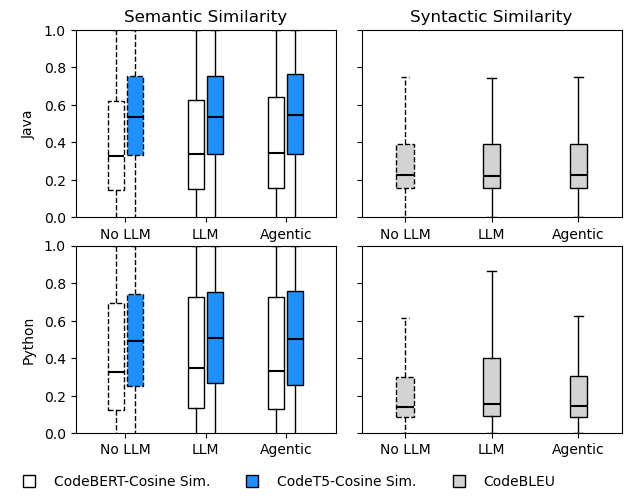

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


plot_df = pd.read_csv("plots/similarity_comparison_data.csv")

model_names = {
    "microsoft/codebert-base-ft": "CodeBERT-Cosine Sim.",
    "Salesforce/codet5-base-ft": "CodeT5-Cosine Sim."
}

languages = plot_df["language"].unique()
models = plot_df["model"].dropna().unique()

# Consistent order for the three conditions
generation_types = [
    "no_llm",
    "llm",
    "agentic"
]

generation_labels = {
    "no_llm": "No LLM",
    "llm": "LLM",
    "agentic": "Agentic"
}

# Colors for the different models (cosine similarity only)
model_colors = {
    models[0]: "white",
    models[1]: "dodgerblue",
}

# Color for CodeBLEU
codebleu_color = "lightgray"


fig, axes = plt.subplots(
    len(languages),
    2,
    figsize=(7, 2.4 * len(languages)),
    squeeze=False
)



# Textual summary


summary = []

for language in languages:

    lang_df = plot_df[plot_df["language"] == language]

    
    # Cosine similarity: one entry per model and generation type
    

    for model in models:

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            summary.append({
                "Language": language.capitalize(),
                "Metric": "Cosine Similarity",
                "Model": model_names[model],
                "Version": generation_labels[generation_type],
                "N": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "Std": values.std(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max()
            })

    
    # CodeBLEU: model-independent, one entry per generation type
    

    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        summary.append({
            "Language": language.capitalize(),
            "Metric": "CodeBLEU",
            "Model": "N/A",
            "Version": generation_labels[generation_type],
            "N": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(),
            "Min": values.min(),
            "Q1": values.quantile(0.25),
            "Q3": values.quantile(0.75),
            "Max": values.max()
        })


summary_df = pd.DataFrame(summary)

display(
    summary_df.style.format({
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "Std": "{:.4f}",
        "Min": "{:.4f}",
        "Q1": "{:.4f}",
        "Q3": "{:.4f}",
        "Max": "{:.4f}"
    })
)



# Plot


# Three groups instead of two
base_positions = {
    "no_llm": 1,
    "llm": 2,
    "agentic": 3
}

# Offsets for the two models in cosine similarity plots
offsets = {
    0: -0.12,
    1:  0.12
}

box_width = 0.20


for row, language in enumerate(languages):

    lang_df = plot_df[plot_df["language"] == language]

    
    # Cosine Similarity
    

    ax = axes[row, 0]

    for model_idx, model in enumerate(models):

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            if values.empty:
                continue

            position = (
                base_positions[generation_type]
                + offsets[model_idx]
            )

            bp = ax.boxplot(
                values,
                positions=[position],
                widths=box_width,
                patch_artist=True,
                showfliers=False
            )

            # Fill color identifies the model
            for patch in bp["boxes"]:
                patch.set_facecolor(model_colors[model])
                patch.set_edgecolor("black")

                # Dashed outline for No LLM
                if generation_type == "no_llm":
                    patch.set_linestyle("--")

            # Whiskers
            for whisker in bp["whiskers"]:
                whisker.set_color("black")

                if generation_type == "no_llm":
                    whisker.set_linestyle("--")

            # Caps
            for cap in bp["caps"]:
                cap.set_color("black")

                if generation_type == "no_llm":
                    cap.set_linestyle("--")

            # Median
            for median in bp["medians"]:
                median.set_color("black")
                median.set_linewidth(1.5)
                median.set_linestyle("-")


    
    # CodeBLEU
    

    ax = axes[row, 1]

    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        if values.empty:
            continue

        position = base_positions[generation_type]

        bp = ax.boxplot(
            values,
            positions=[position],
            widths=box_width,
            patch_artist=True,
            showfliers=False
        )

        # CodeBLEU uses a single color
        for patch in bp["boxes"]:
            patch.set_facecolor(codebleu_color)
            patch.set_edgecolor("black")

            # Dashed outline for No LLM
            if generation_type == "no_llm":
                patch.set_linestyle("--")

        # Whiskers
        for whisker in bp["whiskers"]:
            whisker.set_color("black")

            if generation_type == "no_llm":
                whisker.set_linestyle("--")

        # Caps
        for cap in bp["caps"]:
            cap.set_color("black")

            if generation_type == "no_llm":
                cap.set_linestyle("--")

        # Median
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)
            median.set_linestyle("-")
   

    for col in range(2):

        ax = axes[row, col]

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([
            "No LLM",
            "LLM",
            "Agentic"
        ])

        ax.set_ylim(0, 1)

        # Remove y-axis numbers from right plots
        if col == 1:
            ax.set_yticklabels([])


    # Language label
    axes[row, 0].text(
        -0.18,
        0.5,
        language.capitalize(),
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        ha="center"
    )



# Titles  
axes[0, 0].set_title("Semantic Similarity")
axes[0, 1].set_title("Syntactic Similarity")



# Legend 
legend_handles = []

# Model legend entries for cosine similarity
for model in models:

    handle = plt.Line2D(
        [0],
        [0],
        color="black",
        marker="s",
        markersize=9,
        markerfacecolor=model_colors[model],
        markeredgecolor="black",
        linestyle="None",
        label=model_names[model]
    )

    legend_handles.append(handle)


# CodeBLEU legend entry
codebleu_handle = plt.Line2D(
    [0],
    [0],
    color="black",
    marker="s",
    markersize=9,
    markerfacecolor=codebleu_color,
    markeredgecolor="black",
    linestyle="None",
    label="CodeBLEU"
)

legend_handles.append(codebleu_handle)


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(legend_handles),
    frameon=False
)


# Layout and save 
plt.subplots_adjust(
    wspace=0.10,
    hspace=0.15,
    left=0.2,
    right=0.98,
    bottom=0.08,
    top=0.92
)

Path("plots").mkdir(exist_ok=True)

plt.savefig(
    "plots/similarity_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Paired comparison

In [5]:
df[["sim", "codebleu"]].isna().sum()

sim         0
codebleu    0
dtype: int64

In [6]:
import re

def normalize_project(name):
    # remove the final hash part
    return re.sub(r'_[0-9a-f]{12}$', '', name)

df["project_group"] = df["project"].apply(normalize_project)

In [7]:
# Show all LLM entries
llm_df = (
    df[df["generation_type"] == "llm"]
    [["file", "file_index", "project", "language"]]
    .drop_duplicates()
    .sort_values(["file_index", "project", "language"])
)

display(llm_df.head(50))

,file,file_index,project,language
51214,0001_RockyLOMO_rxlib_ee74de713ebf_detailed_res...,1,RockyLOMO_rxlib,java
527658,0004_cgeo_cgeo_8f983a7b79e6_detailed_results.json,4,cgeo_cgeo,java
1310346,0007_fr3ts0n_AndrOBD_7bf7133fb972_detailed_res...,7,fr3ts0n_AndrOBD,java
1445614,0010_Zettelkasten-Team_Zettelkasten_b2b3484326...,10,Zettelkasten-Team_Zettelkasten,java
1954078,0013_AdamaJava_adamajava_e3968a72f476_detailed...,13,AdamaJava_adamajava,java
2641208,0016_ta4j_ta4j_ccaee65ff838_detailed_results.json,16,ta4j_ta4j,java
4771626,0019_sakaiproject_sakai_9cda7021efa3_detailed_...,19,sakaiproject_sakai,java
8393152,0022_Iterable_iterable-android-sdk_8fdec83bb64...,22,Iterable_iterable-android-sdk,java
8882376,0025_wso2_carbon-identity-framework_f70492edb2...,25,wso2_carbon-identity-framework,java
10305442,0028_GoogleCloudPlatform_DataflowTemplates_8e7...,28,GoogleCloudPlatform_DataflowTemplates,java


In [8]:
project_scores = (
    df
    .groupby(
        ["project", "language", "generation_type"]
    )[["sim", "codebleu"]]
    .mean()
    .reset_index()
)

comparison = project_scores.pivot_table(
    index=["project", "language"],
    columns="generation_type",
    values=["sim", "codebleu"]
)

comparison.columns = [
    f"{metric}_{generation_type}"
    for metric, generation_type in comparison.columns
]

comparison["sim_llm_change"] = (
    comparison["sim_llm"] - comparison["sim_no_llm"]
)

comparison["sim_agentic_change"] = (
    comparison["sim_agentic"] - comparison["sim_no_llm"]
)

comparison["codebleu_llm_change"] = (
    comparison["codebleu_llm"] - comparison["codebleu_no_llm"]
)

comparison["codebleu_agentic_change"] = (
    comparison["codebleu_agentic"] - comparison["codebleu_no_llm"]
)



## Evolution

In [ ]:
stats_by_language = (
    comparison
    .groupby("language")[
        [
            "sim_llm_change",
            "sim_agentic_change",
            "codebleu_llm_change",
            "codebleu_agentic_change"
        ]
    ]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

display(stats_by_language)

sim_llm_change                                                  \
                  count      mean    median     std       min       max   
language                                                                  
java                 24  0.004691  0.004529  0.0259  -0.07331  0.068366   
python               26  0.013549  0.000122  0.0488 -0.099528  0.133477   

         sim_agentic_change                              ...  \
                      count      mean    median     std  ...   
language                                                 ...   
java                     24  0.004592  0.002834  0.0262  ...   
python                   25  0.023186  0.015583  0.0588  ...   

         codebleu_llm_change                              \
                      median     std       min       max   
language                                                   
java                0.000831  0.0343 -0.124207  0.063694   
python              0.000956  0.0365 -0.035849  0.133156   

         codebleu_agentic_change                                        \
                           count      mean    median     std       min   
language                                                                 
java                          24 -0.006268 -0.002639  0.0353 -0.124463   
python                        25  0.018072  0.006762  0.0369 -0.026608   

                    
               max  
language            
java      0.049935  
python    0.128907  

[2 rows x 24 columns]

: 